In [1]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from scipy import integrate
import pickle
from scipy.stats import binned_statistic
import random
from NFWdist import *

In [2]:
snapnum = 40
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200", "Group_R_TopHat200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [3]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [4]:
mvirs = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [43]:
logMs = np.arange(11,14.6, 0.5)

result_list = []

for i, logM in enumerate(logMs[:-1]):
    logMmin = logM
    logMmax = logMs[i+1]
    mask = (mvirs > logMmin) & (mvirs < logMmax)
    groupsfrs = halos["GroupSFR"][mask]
    haloids = np.arange(0,len(halos["GroupSFR"]),1)[mask]

    mask_in = np.isin(subhalos["SubhaloGrNr"],haloids)
    gal_sfrs = subhalos["SubhaloSFR"][mask_in]

    W_h_squared = np.sum(groupsfrs**2)
    W_g_squared = np.sum(gal_sfrs**2)
    result = W_h_squared - W_g_squared
    result_list.append(result)



In [44]:

print(result)

609057.06


In [46]:
logM_bin_cents = (logMs[:-1] + logMs[1:])/2

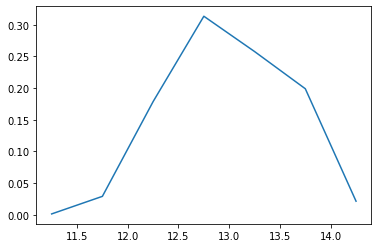

In [48]:
plt.plot(logM_bin_cents, result_list/np.sum(result_list))